**TASK A — Visualization of Activation Functions**

Cell 1 — Imports

In [8]:
# EXPT NO: 2
# Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning
# Name:AJAIKUMAR M
# Roll No:24BAD005

import numpy as np
import matplotlib.pyplot as plt

Cell 2 — Define activation functions

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

Cell 3 — Generate input values

In [10]:
x = np.linspace(-10, 10, 1000)

Cell 4 — Plot

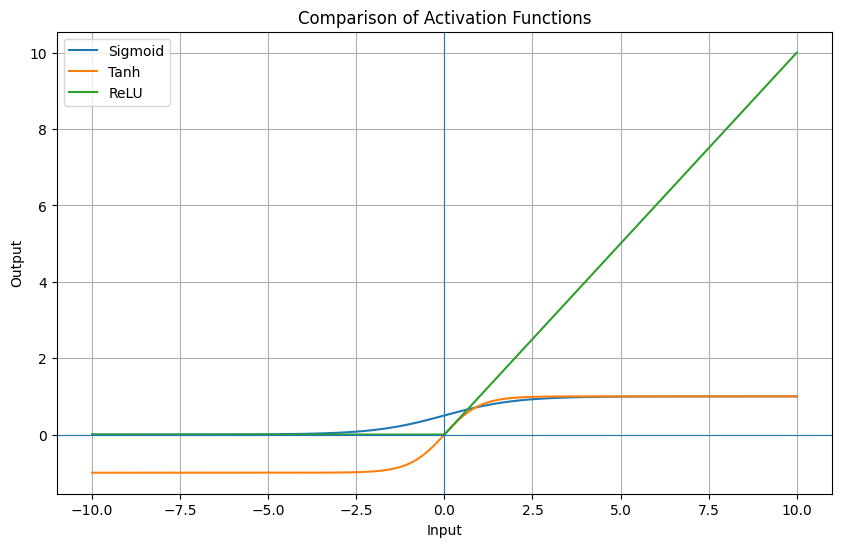

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, tanh(x), label='Tanh')
plt.plot(x, relu(x), label='ReLU')

plt.title('Comparison of Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.legend()
plt.grid(True)
plt.show()

**TASK B — Performance Comparison of Activation Functions**

For this task, we'll use the MNIST handwritten-digit dataset and keep the ANN architecture the same while changing only the activation function.

Cell 1 — Import TensorFlow

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

Cell 2 — Load dataset

In [13]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


Cell 3 — Create validation data

In [14]:
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train_new = x_train[:-10000]
y_train_new = y_train[:-10000]

print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test.shape)

Training: (50000, 28, 28)
Validation: (10000, 28, 28)
Testing: (10000, 28, 28)


Cell 4 — Function to create ANN

In [15]:
def create_model(activation):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation=activation),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Cell 5 — Train with Sigmoid

In [16]:
sigmoid_model = create_model('sigmoid')

history_sigmoid = sigmoid_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8023 - loss: 0.8948 - val_accuracy: 0.9187 - val_loss: 0.3407
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9188 - loss: 0.2982 - val_accuracy: 0.9387 - val_loss: 0.2256
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9367 - loss: 0.2208 - val_accuracy: 0.9500 - val_loss: 0.1840
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9480 - loss: 0.1785 - val_accuracy: 0.9550 - val_loss: 0.1578
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9570 - loss: 0.1481 - val_accuracy: 0.9610 - val_loss: 0.1401
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9645 - loss: 0.1246 - val_accuracy: 0.9653 - val_loss: 0.1225
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9694 - loss: 0.1071 - val_accuracy: 0.9673 - val_loss: 0.1150
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9742 - loss: 0.0921 - val_accuracy: 0.

Cell 6 — Train with Tanh

In [17]:
tanh_model = create_model('tanh')

history_tanh = tanh_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8925 - loss: 0.3827 - val_accuracy: 0.9438 - val_loss: 0.2076
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9472 - loss: 0.1836 - val_accuracy: 0.9575 - val_loss: 0.1524
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9620 - loss: 0.1309 - val_accuracy: 0.9657 - val_loss: 0.1161
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9709 - loss: 0.0992 - val_accuracy: 0.9701 - val_loss: 0.1008
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0756 - val_accuracy: 0.9706 - val_loss: 0.0991
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9824 - loss: 0.0606 - val_accuracy: 0.9733 - val_loss: 0.0900
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9866 - loss: 0.0476 - val_accuracy: 0.9710 - val_loss: 0.0896
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9887 - loss: 0.0397 - val_accuracy: 0

Cell 7 — Train with ReLU

In [18]:
relu_model = create_model('relu')

history_relu = relu_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8947 - loss: 0.3711 - val_accuracy: 0.9527 - val_loss: 0.1640
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9571 - loss: 0.1480 - val_accuracy: 0.9639 - val_loss: 0.1205
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9692 - loss: 0.1033 - val_accuracy: 0.9707 - val_loss: 0.0952
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9766 - loss: 0.0779 - val_accuracy: 0.9722 - val_loss: 0.0930
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9820 - loss: 0.0603 - val_accuracy: 0.9722 - val_loss: 0.0912
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0491 - val_accuracy: 0.9752 - val_loss: 0.0815
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9746 - val_loss: 0.0836
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9898 - loss: 0.0326 - val_accuracy: 0.

Cell 8 — Compare final accuracy

In [19]:
print("Final Training Accuracy")
print("------------------------")
print("Sigmoid:", history_sigmoid.history['accuracy'][-1])
print("Tanh   :", history_tanh.history['accuracy'][-1])
print("ReLU   :", history_relu.history['accuracy'][-1])

print("\nFinal Validation Accuracy")
print("-------------------------")
print("Sigmoid:", history_sigmoid.history['val_accuracy'][-1])
print("Tanh   :", history_tanh.history['val_accuracy'][-1])
print("ReLU   :", history_relu.history['val_accuracy'][-1])

Final Training Accuracy
------------------------
Sigmoid: 0.9805399775505066
Tanh   : 0.9937800168991089
ReLU   : 0.9933199882507324

Final Validation Accuracy
-------------------------
Sigmoid: 0.9731000065803528
Tanh   : 0.9767000079154968
ReLU   : 0.9746000170707703


Cell 9 — Compare training accuracy

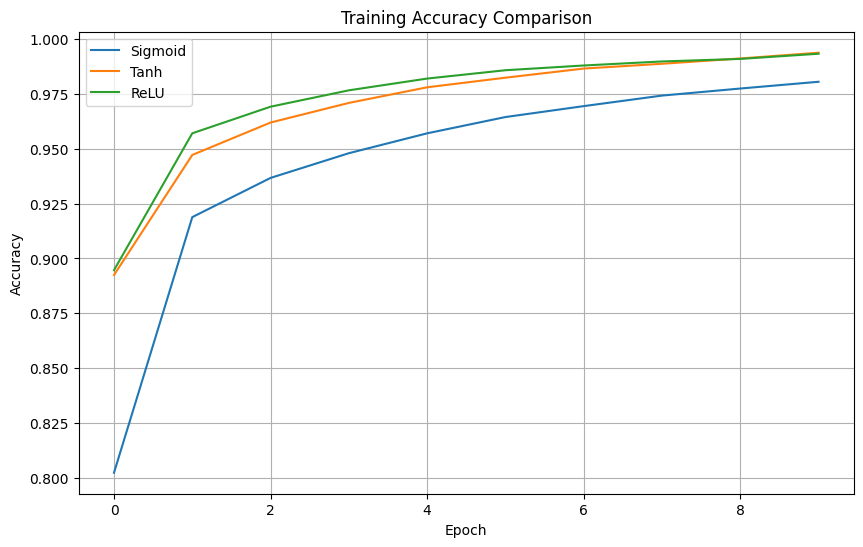

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(history_sigmoid.history['accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['accuracy'], label='Tanh')
plt.plot(history_relu.history['accuracy'], label='ReLU')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Cell 10 — Compare validation accuracy

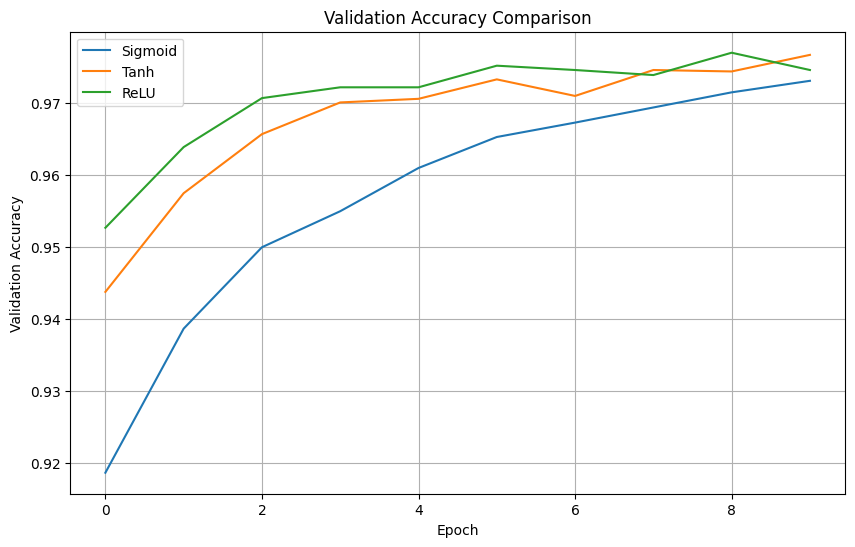

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')
plt.plot(history_relu.history['val_accuracy'], label='ReLU')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Cell 11 — Compare training loss

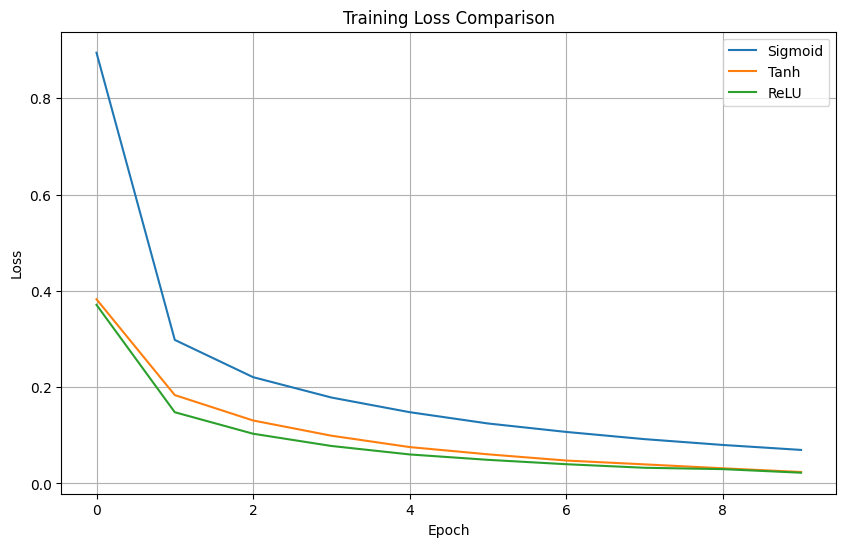

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(history_sigmoid.history['loss'], label='Sigmoid')
plt.plot(history_tanh.history['loss'], label='Tanh')
plt.plot(history_relu.history['loss'], label='ReLU')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Cell 12 — Compare validation loss

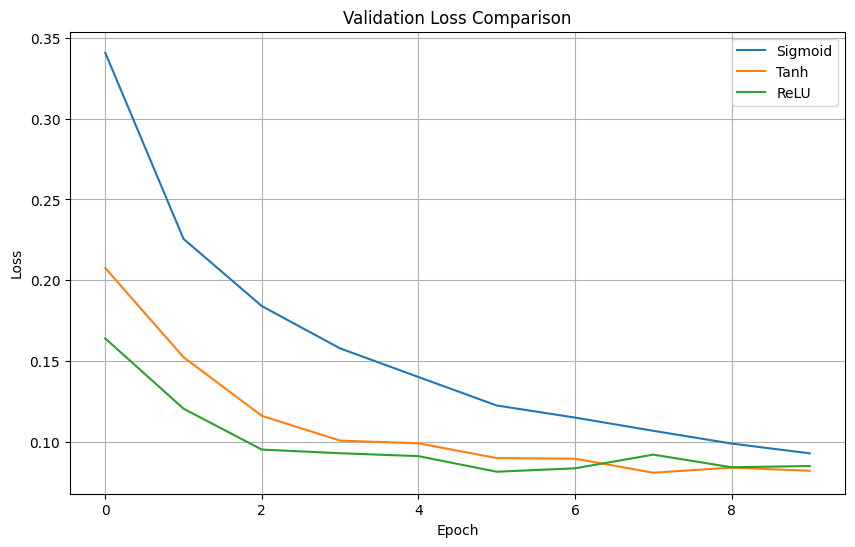

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(history_tanh.history['val_loss'], label='Tanh')
plt.plot(history_relu.history['val_loss'], label='ReLU')

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**TASK C — Optimization Algorithm Comparison**

Here we'll use ReLU for the hidden layers and compare:

SGD,
Momentum,
RMSProp,
Adam

Cell 1 — Create optimizer models

In [24]:
def create_optimizer_model(optimizer):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Cell 2 — Define optimizers

In [25]:
sgd = tf.keras.optimizers.SGD(learning_rate=0.01)

momentum = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

rmsprop = tf.keras.optimizers.RMSprop(
    learning_rate=0.001
)

adam = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

Cell 3 — Train SGD

In [26]:
sgd_model = create_optimizer_model(sgd)

history_sgd = sgd_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6554 - loss: 1.3705 - val_accuracy: 0.8481 - val_loss: 0.6866
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8542 - loss: 0.5717 - val_accuracy: 0.8889 - val_loss: 0.4290
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8844 - loss: 0.4266 - val_accuracy: 0.9016 - val_loss: 0.3549
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8964 - loss: 0.3693 - val_accuracy: 0.9094 - val_loss: 0.3192
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9042 - loss: 0.3359 - val_accuracy: 0.9164 - val_loss: 0.2966
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9105 - loss: 0.3125 - val_accuracy: 0.9197 - val_loss: 0.2808
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9157 - loss: 0.2938 - val_accuracy: 0.9245 - val_loss: 0.2646
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9202 - loss: 0.2785 - val_accuracy: 0.

Cell 4 — Train Momentum

In [27]:
momentum_model = create_optimizer_model(momentum)

history_momentum = momentum_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8450 - loss: 0.5468 - val_accuracy: 0.9270 - val_loss: 0.2578
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9311 - loss: 0.2382 - val_accuracy: 0.9475 - val_loss: 0.1878
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9483 - loss: 0.1786 - val_accuracy: 0.9539 - val_loss: 0.1586
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9578 - loss: 0.1447 - val_accuracy: 0.9632 - val_loss: 0.1323
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9652 - loss: 0.1190 - val_accuracy: 0.9640 - val_loss: 0.1296
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9705 - loss: 0.1020 - val_accuracy: 0.9690 - val_loss: 0.1085
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9738 - loss: 0.0895 - val_accuracy: 0.9700 - val_loss: 0.1000
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9774 - loss: 0.0786 - val_accuracy: 0.

Cell 5 — Train RMSProp

In [28]:
rmsprop_model = create_optimizer_model(rmsprop)

history_rmsprop = rmsprop_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8999 - loss: 0.3486 - val_accuracy: 0.9507 - val_loss: 0.1679
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9555 - loss: 0.1501 - val_accuracy: 0.9637 - val_loss: 0.1275
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9691 - loss: 0.1037 - val_accuracy: 0.9706 - val_loss: 0.0993
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9759 - loss: 0.0790 - val_accuracy: 0.9723 - val_loss: 0.0926
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9808 - loss: 0.0621 - val_accuracy: 0.9713 - val_loss: 0.0976
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9842 - loss: 0.0509 - val_accuracy: 0.9742 - val_loss: 0.0909
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0420 - val_accuracy: 0.9763 - val_loss: 0.0859
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9893 - loss: 0.0342 - val_accuracy: 0.

Cell 6 — Train Adam

In [29]:
adam_model = create_optimizer_model(adam)

history_adam = adam_model.fit(
    x_train_new,
    y_train_new,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8958 - loss: 0.3670 - val_accuracy: 0.9465 - val_loss: 0.1847
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9546 - loss: 0.1532 - val_accuracy: 0.9640 - val_loss: 0.1287
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9682 - loss: 0.1076 - val_accuracy: 0.9691 - val_loss: 0.1082
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9755 - loss: 0.0830 - val_accuracy: 0.9727 - val_loss: 0.0906
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9802 - loss: 0.0652 - val_accuracy: 0.9741 - val_loss: 0.0875
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9837 - loss: 0.0538 - val_accuracy: 0.9710 - val_loss: 0.0991
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9871 - loss: 0.0429 - val_accuracy: 0.9780 - val_loss: 0.0746
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9892 - loss: 0.0349 - val_accuracy: 0.

Cell 7 — Training Loss comparison

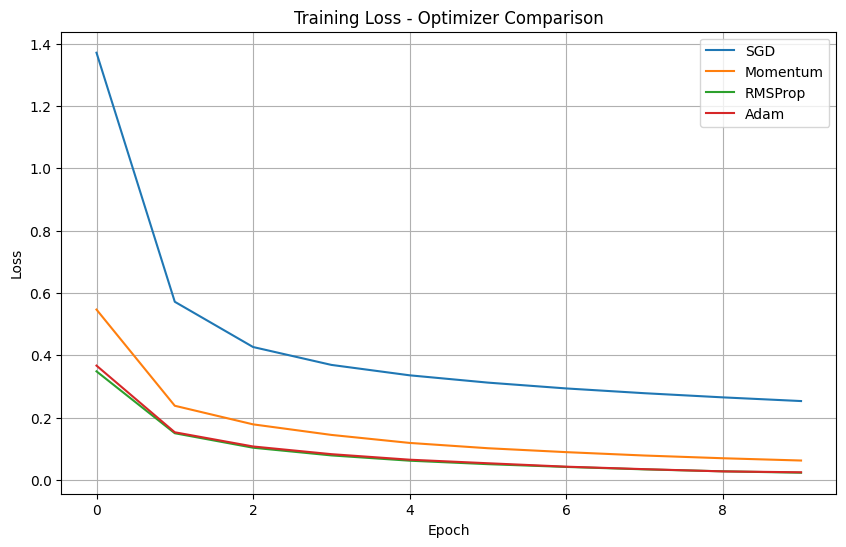

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_momentum.history['loss'], label='Momentum')
plt.plot(history_rmsprop.history['loss'], label='RMSProp')
plt.plot(history_adam.history['loss'], label='Adam')

plt.title('Training Loss - Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Cell 8 — Validation Loss comparison

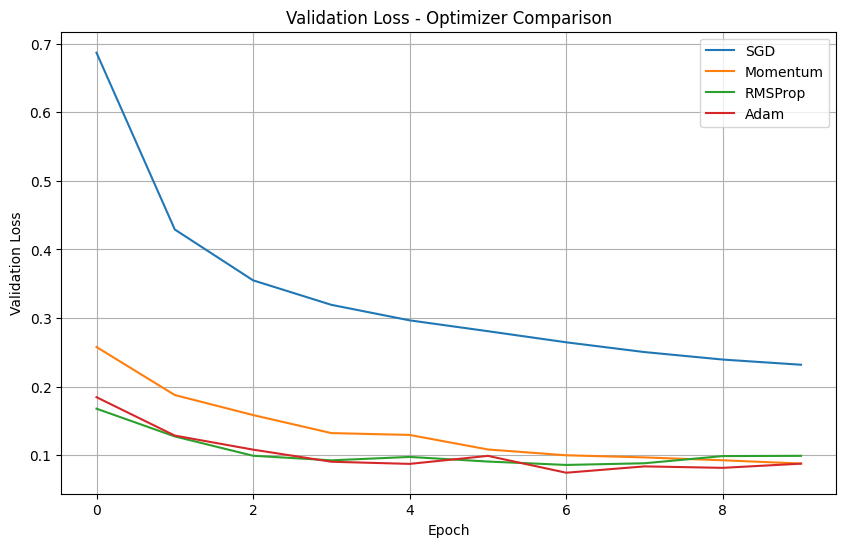

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_momentum.history['val_loss'], label='Momentum')
plt.plot(history_rmsprop.history['val_loss'], label='RMSProp')
plt.plot(history_adam.history['val_loss'], label='Adam')

plt.title('Validation Loss - Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Cell 9 — Training Accuracy

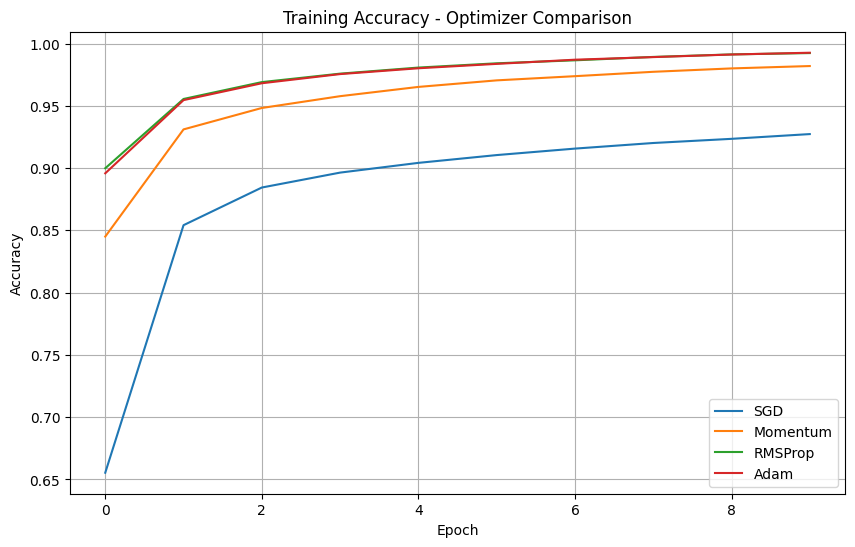

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_momentum.history['accuracy'], label='Momentum')
plt.plot(history_rmsprop.history['accuracy'], label='RMSProp')
plt.plot(history_adam.history['accuracy'], label='Adam')

plt.title('Training Accuracy - Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Cell 10 — Validation Accuracy

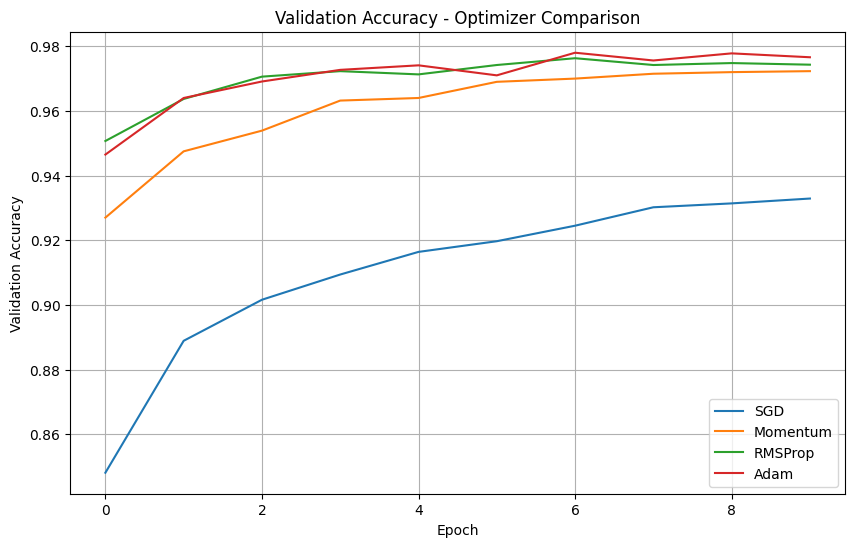

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_momentum.history['val_accuracy'], label='Momentum')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSProp')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.title('Validation Accuracy - Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Cell 11 — Final comparison

In [34]:
print("FINAL OPTIMIZER COMPARISON")
print("=" * 50)

print("SGD")
print("Training Accuracy :", history_sgd.history['accuracy'][-1])
print("Validation Accuracy:", history_sgd.history['val_accuracy'][-1])

print("\nMomentum")
print("Training Accuracy :", history_momentum.history['accuracy'][-1])
print("Validation Accuracy:", history_momentum.history['val_accuracy'][-1])

print("\nRMSProp")
print("Training Accuracy :", history_rmsprop.history['accuracy'][-1])
print("Validation Accuracy:", history_rmsprop.history['val_accuracy'][-1])

print("\nAdam")
print("Training Accuracy :", history_adam.history['accuracy'][-1])
print("Validation Accuracy:", history_adam.history['val_accuracy'][-1])

FINAL OPTIMIZER COMPARISON
SGD
Training Accuracy : 0.9273399710655212
Validation Accuracy: 0.9329000115394592

Momentum
Training Accuracy : 0.98198002576828
Validation Accuracy: 0.9722999930381775

RMSProp
Training Accuracy : 0.9923999905586243
Validation Accuracy: 0.9743000268936157

Adam
Training Accuracy : 0.992680013179779
Validation Accuracy: 0.9765999913215637


In [35]:
print("sigmoid_model" in globals())
print("tanh_model" in globals())
print("relu_model" in globals())
print("sgd_model" in globals())
print("momentum_model" in globals())
print("rmsprop_model" in globals())
print("adam_model" in globals())

True
True
True
True
True
True
True


In [36]:
sigmoid_model.save("sigmoid_model.keras")
tanh_model.save("tanh_model.keras")
relu_model.save("relu_model.keras")

sgd_model.save("sgd_model.keras")
momentum_model.save("momentum_model.keras")
rmsprop_model.save("rmsprop_model.keras")
adam_model.save("adam_model.keras")

print("All models saved successfully!")

All models saved successfully!


In [37]:
import os

for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

sigmoid_model.keras
relu_model.keras
momentum_model.keras
rmsprop_model.keras
tanh_model.keras
adam_model.keras
sgd_model.keras
